# Global alltime EDA
Utforskar datan på en global nivå.

In [40]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path

# Läs in data
DATA_PATH = Path("../../data/processed")
df = pd.read_csv(DATA_PATH / "2026-02-08_global_alltime.csv", sep=';', encoding='utf-8')

# Skapa användbara kolumner
df['media_type'] = df['category'].apply(lambda x: 'Film' if 'Films' in x else 'TV')
df['language'] = df['category'].apply(lambda x: 'English' if 'English' in x else 'Non-English')

# Registrera DataFrame i DuckDB
duckdb.register("global_alltime", df)

# Stil för matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

### Skapa querys och tar hjälp av duckdb

1. Vilken film eller TV-serie har flest visningstimmar globalt?

In [41]:
# Använder cumulative_weeks_in_top_10 som mått på framgång
query = """
    SELECT 
        media_type,
        SUM(cumulative_weeks_in_top_10) AS total_weeks
    FROM global_alltime
    GROUP BY media_type
    ORDER BY total_weeks DESC
"""
result = duckdb.sql(query).df()
print("=== Fördelning film/TV globalt ===\n")
for _, row in result.iterrows():
    print(f"{row['media_type']}: {row['total_weeks']} veckor")

=== Fördelning film/TV globalt ===

TV: 18175.0 veckor
Film: 13845.0 veckor


2. Titlar som förekommer både som film och TV-serier

In [42]:
# Jämför genomsnittlig speltid mellan film och TV-serier
query = """
    WITH film_titles AS (
        SELECT DISTINCT show_title
        FROM global_alltime
        WHERE media_type = 'Film'
    ),
    tv_titles AS (
        SELECT DISTINCT show_title
        FROM global_alltime
        WHERE media_type = 'TV'
    )
    SELECT show_title
    FROM film_titles
    INTERSECT
    SELECT show_title
    FROM tv_titles
    ORDER BY show_title
    LIMIT 15
"""
common_titles = duckdb.sql(query).df()
print("=== Titlar som förekommer både som film och TV ===\n")
for title in common_titles['show_title']:
    print(f"• {title}")
print("\nVisar 15 av många titlar")

count = duckdb.sql("""
    SELECT COUNT(*) AS common_count FROM (
        SELECT show_title FROM global_alltime WHERE media_type='Film'
        INTERSECT
        SELECT show_title FROM global_alltime WHERE media_type='TV'
    )
""").df().iloc[0,0]
print(f"\nTotalt {count} titlar förekommer i båda kategorierna.")

=== Titlar som förekommer både som film och TV ===

• Alone
• First Kill
• Furies
• Hierarchy
• The Diplomat
• The Gentlemen
• The Stranger
• Zom 100: Bucket List of the Dead

Visar 15 av många titlar

Totalt 8 titlar förekommer i båda kategorierna.


3. Engelska vs icke-engelska titlar: andel av totala veckor

In [43]:
# Fördelning engelska vs icke-engelska titlar
query = """
    SELECT 
        language,
        SUM(cumulative_weeks_in_top_10) AS total_weeks
    FROM global_alltime
    GROUP BY language
    ORDER BY total_weeks DESC
"""
lang_result = duckdb.sql(query).df()
print("=== Fördelning engelska/icke-engelska ===\n")
for _, row in lang_result.iterrows():
    print(f"{row['language']}: {row['total_weeks']} veckor")

winner = lang_result.iloc[0]['language']
print(f"\n🏆 {winner} har flest veckor i topp 10 totalt!")

=== Fördelning engelska/icke-engelska ===

English: 32020.0 veckor

🏆 English har flest veckor i topp 10 totalt!


4. Titlar som hållit sig längst i topp 10

In [44]:
# Längsta löparen i topp 10
query = """
    SELECT 
        show_title,
        media_type,
        MAX(cumulative_weeks_in_top_10) AS max_weeks
    FROM global_alltime
    GROUP BY show_title, media_type
    HAVING MAX(cumulative_weeks_in_top_10) >= 10
    ORDER BY max_weeks DESC
    LIMIT 10
"""
long_running = duckdb.sql(query).df()
print("=== Titlar som hållit sig kvar i topp 10 längst (>=10 veckor) ===\n")
for _, row in long_running.iterrows():
    print(f"{row['show_title']} ({row['media_type']}) – {row['max_weeks']} veckor")

top = long_running.iloc[0]
print(f"\n🏆 Längsta löparen: '{top['show_title']}' med {top['max_weeks']} veckor!")

=== Titlar som hållit sig kvar i topp 10 längst (>=10 veckor) ===

KPop Demon Hunters (Film) – 39 veckor
Squid Game (TV) – 32 veckor
Yo soy Betty, la fea (TV) – 30 veckor
Stranger Things (TV) – 29 veckor
Wednesday (TV) – 28 veckor
Café con aroma de mujer (TV) – 28 veckor
Manifest (TV) – 25 veckor
Ms. Rachel (TV) – 25 veckor
The Super Mario Bros. Movie (Film) – 24 veckor
The Boss Baby (Film) – 24 veckor

🏆 Längsta löparen: 'KPop Demon Hunters' med 39 veckor!


5. Antal veckor i topp 10 per film/tv-serier och språk

In [45]:
# Antal veckor och unika titlar per film/tv-serier och språk
query = """
    SELECT 
        media_type,
        language,
        SUM(cumulative_weeks_in_top_10) AS total_weeks,
        COUNT(DISTINCT show_title) AS unique_titles
    FROM global_alltime
    GROUP BY media_type, language
    ORDER BY total_weeks DESC
"""
result = duckdb.sql(query).df()
print("=== Antal veckor och unika titlar per medietyp och språk ===\n")
for _, row in result.iterrows():
    print(f"{row['media_type']} ({row['language']}): {row['total_weeks']} veckor, {row['unique_titles']} unika titlar")

=== Antal veckor och unika titlar per medietyp och språk ===

TV (English): 18175.0 veckor, 1152 unika titlar
Film (English): 13845.0 veckor, 2001 unika titlar


### Visualisera querys i grafer och diagram

1. De 5 filmerna med flest totala veckor i topp 10

Topp 5 filmer globalt:
                       show_title  total_weeks
0              KPop Demon Hunters        780.0
1     The Super Mario Bros. Movie        300.0
2                   The Boss Baby        300.0
3  All Quiet on the Western Front        276.0
4                     Under Paris        231.0


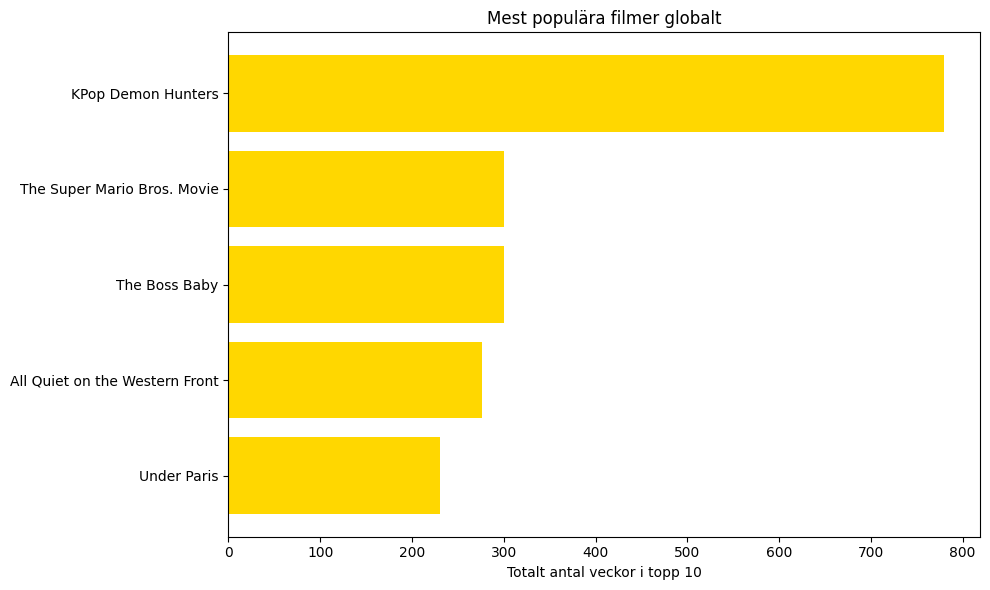

In [46]:
# Med hjälp av cumulative_weeks_in_top_10
query = """
    SELECT 
        show_title,
        SUM(cumulative_weeks_in_top_10) AS total_weeks
    FROM global_alltime
    WHERE media_type = 'Film'
    GROUP BY show_title
    ORDER BY total_weeks DESC
    LIMIT 5
"""
top_films = duckdb.sql(query).df()
print("Topp 5 filmer globalt:")
print(top_films)

plt.barh(top_films['show_title'], top_films['total_weeks'], color='gold')
plt.xlabel('Totalt antal veckor i topp 10')
plt.title('Mest populära filmer globalt')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

2. Jämförelse: genomsnittlig kumulativ veckor per film/tv-serier och språk

  media_type language  avg_weeks
0       Film  English   2.814024
1         TV  English   3.694106


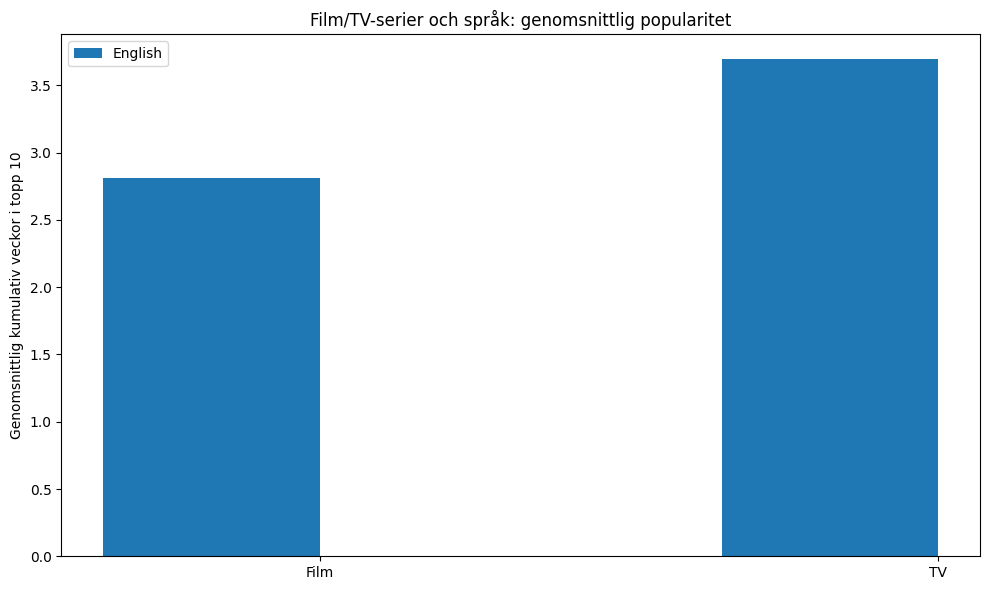

In [47]:
query = """
    SELECT 
        media_type,
        language,
        AVG(cumulative_weeks_in_top_10) AS avg_weeks
    FROM global_alltime
    GROUP BY media_type, language
    ORDER BY media_type, language
"""
avg_data = duckdb.sql(query).df()
print(avg_data)

# Grupperat stapeldiagram
import numpy as np
categories = avg_data['media_type'].unique()
languages = avg_data['language'].unique()
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots()
for i, lang in enumerate(languages):
    subset = avg_data[avg_data['language'] == lang]
    values = [subset[subset['media_type'] == cat]['avg_weeks'].values[0] if not subset[subset['media_type'] == cat].empty else 0 for cat in categories]
    ax.bar(x + i*width, values, width, label=lang)

ax.set_ylabel('Genomsnittlig kumulativ veckor i topp 10')
ax.set_title('Film/TV-serier och språk: genomsnittlig popularitet')
ax.set_xticks(x + width/2)
ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.show()

3. Nya titlar per månad, första gången en titel dyker upp i topp 10

    month  new_titles
0       1         268
1       2         254
2       3         276
3       4         220
4       5         220
5       6         217
6       7         305
7       8         268
8       9         279
9      10         305
10     11         274
11     12         267


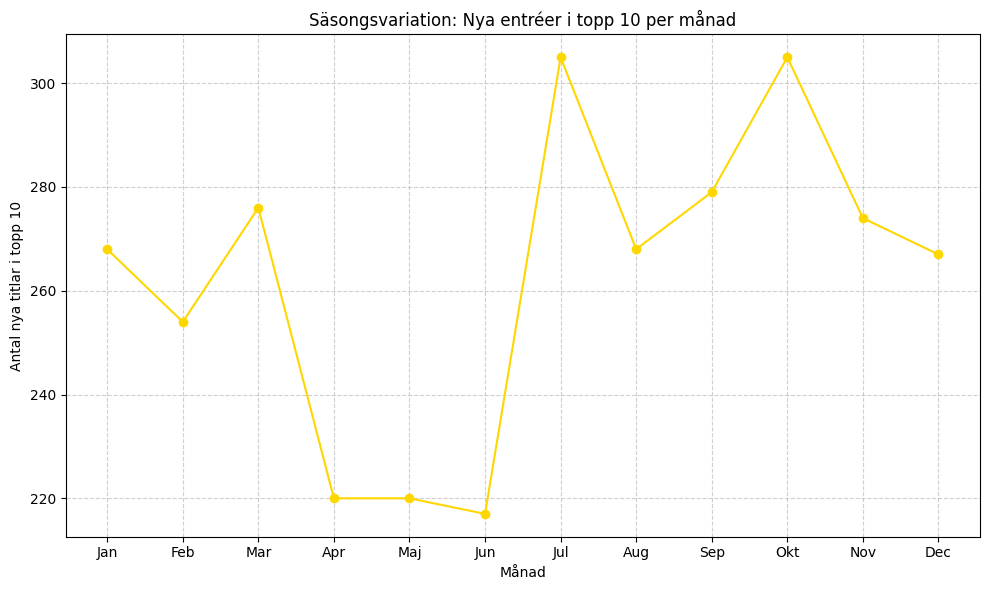

In [48]:
# Använder show_title, media_type och första veckan i topp 10 för att analysera
query = """
    SELECT 
        show_title,
        media_type,
        MIN(week) as first_week
    FROM global_alltime
    WHERE weekly_rank <= 10
    GROUP BY show_title, media_type
"""
first_appearance = duckdb.sql(query).df()
first_appearance['month'] = pd.to_datetime(first_appearance['first_week']).dt.month

monthly_new = first_appearance.groupby('month').size().reset_index(name='new_titles')
monthly_new = monthly_new.sort_values('month')
print(monthly_new)

plt.plot(monthly_new['month'], monthly_new['new_titles'], marker='o', linestyle='-', color='gold')
plt.xlabel('Månad')
plt.ylabel('Antal nya titlar i topp 10')
plt.title('Säsongsvariation: Nya entréer i topp 10 per månad')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','Maj','Jun','Jul','Aug','Sep','Okt','Nov','Dec'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

4. En specifik titels popularitet över tid, exempel: "Kpop Demon Hunters"

          week  views_millions
0   2025-06-22             9.2
1   2025-06-29            24.2
2   2025-07-06            22.7
3   2025-07-13            24.2
4   2025-07-20            25.8
5   2025-07-27            26.3
6   2025-08-03            26.3
7   2025-08-10            25.9
8   2025-08-17            26.0
9   2025-08-24            25.4
10  2025-08-31            30.1
11  2025-09-07            25.4
12  2025-09-14            22.6
13  2025-09-21            21.2
14  2025-09-28            19.3
15  2025-10-05            18.1
16  2025-10-12            17.8
17  2025-10-19            16.2
18  2025-10-26            14.6
19  2025-11-02            14.0
20  2025-11-09            12.4
21  2025-11-16            11.6
22  2025-11-23            10.1
23  2025-11-30            10.4
24  2025-12-07             8.6
25  2025-12-14             8.0
26  2025-12-21             7.9
27  2025-12-28             9.1
28  2026-01-04             9.4
29  2026-01-11             7.6
30  2026-01-18             7.3
31  2026

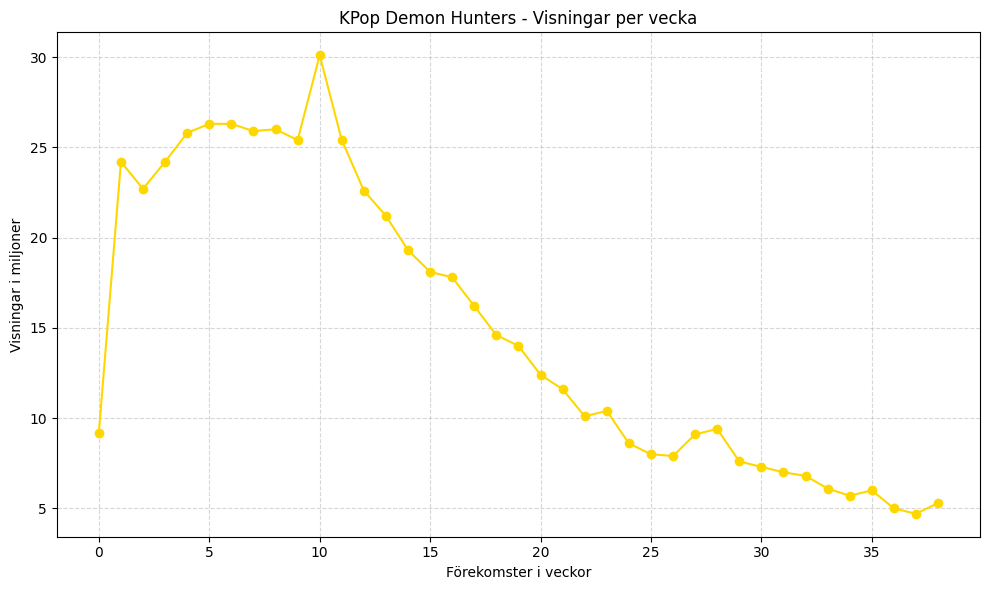

In [49]:
# Trend över tid för en specifik titel
title = "KPop Demon Hunters"
query = f"""
    SELECT 
        week,
        weekly_views / 1e6 AS views_millions
    FROM global_alltime
    WHERE show_title = '{title}'
      AND weekly_views IS NOT NULL
    ORDER BY week
"""
trend = duckdb.sql(query).df()
print(trend)

plt.plot(range(len(trend)), trend['views_millions'], marker='o', linestyle='-', color='gold')
plt.xlabel('Förekomster i veckor')
plt.ylabel('Visningar i miljoner')
plt.title(f'{title} - Visningar per vecka')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Sammanfattning
Vad datan säger.
- *Film vs TV-series*: TV-series dominerar totala veckor i topp 10.
- *Språk*: Engelskt material har betydligt fler veckor än icke-engelskt.
- *Långlivade titlar*: "Paw Patrol: The Movie" och "Kpop Demon Hunters" ligger längst.
- *Säsongsmönster*: Oktober har flest nya titlar, april minst.
- *Speltid*: Filmer tenderar att vara kortare än tv-serier.